In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor
import matplotlib.pyplot as plt


In [8]:
import pandas as pd

# Load cleaned datasets
sales = pd.read_csv(r"C:\Users\TANU\Documents\EDA\sales_cleaned.csv")
models = pd.read_csv(r"C:\Users\TANU\Documents\EDA\MobileModels.csv")
customers = pd.read_csv(r"C:\Users\TANU\Documents\EDA\Customers.csv")
shops = pd.read_csv(r"C:\Users\TANU\Documents\EDA\ShopLocations.csv")

# Step 1: Merge sales + models
df1 = pd.merge(sales, models, on="model_id", how="left")

# Step 2: Merge sales + shops
df2 = pd.merge(df1, shops, on="shop_id", how="left")

# Step 3: Merge sales + customers
df3 = pd.merge(df2, customers[["customer_id", "city"]], on="customer_id", how="left")

# Step 4: Add revenue field
df3["revenue"] = df3["quantity"] * df3["final_price"]

# FINAL PREDICTIVE DATASET (correct columns)
predict_df = df3[[  
    "final_price",
    "revenue",
    "discount",
    "brand_x",          # <- correct brand column
    "ram_gb_x",         # <- correct RAM column
    "storage_gb_x",     # <- correct Storage column
    "rating",           # from Shops.csv
    "city"
]]

# Rename columns to clean names
predict_df = predict_df.rename(columns={
    "brand_x": "brand",
    "ram_gb_x": "ram_gb",
    "storage_gb_x": "storage_gb"
})

print("Predictive Dataset Created:")
print(predict_df.head())

# SAVE
save_path = r"C:\Users\TANU\Documents\EDA\regression_dataset.csv"
predict_df.to_csv(save_path, index=False)

print("\n✔ regression_dataset.csv saved successfully at:")
print(save_path)


Predictive Dataset Created:
   final_price   revenue  discount     brand  ram_gb  storage_gb  rating  \
0     22316.19  22316.19      1.05    realme       4          64     4.8   
1     26218.62  26218.62     10.48   Samsung       4         256     5.0   
2     36469.80  72939.60     13.55     Apple       6         128     3.5   
3     37230.80  37230.80      7.57     Apple      12          64     3.3   
4     35201.29  35201.29     18.79  Motorola       6          64     4.2   

        city  
0  Bangalore  
1   Ahmedbad  
2   Kolkatta  
3     Jaipur  
4   Hydrabad  

✔ regression_dataset.csv saved successfully at:
C:\Users\TANU\Documents\EDA\regression_dataset.csv


In [10]:
import pandas as pd

df = pd.read_csv(r"C:\Users\TANU\Documents\EDA\regression_dataset.csv")
print(df.head())
print(df.info())


   final_price   revenue  discount     brand  ram_gb  storage_gb  rating  \
0     22316.19  22316.19      1.05    realme       4          64     4.8   
1     26218.62  26218.62     10.48   Samsung       4         256     5.0   
2     36469.80  72939.60     13.55     Apple       6         128     3.5   
3     37230.80  37230.80      7.57     Apple      12          64     3.3   
4     35201.29  35201.29     18.79  Motorola       6          64     4.2   

        city  
0  Bangalore  
1   Ahmedbad  
2   Kolkatta  
3     Jaipur  
4   Hydrabad  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   final_price  40000 non-null  float64
 1   revenue      40000 non-null  float64
 2   discount     40000 non-null  float64
 3   brand        40000 non-null  object 
 4   ram_gb       40000 non-null  int64  
 5   storage_gb   40000 non-null  int64  
 6   rati

In [12]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

le_brand = LabelEncoder()
le_city = LabelEncoder()

df_encoded["brand"] = le_brand.fit_transform(df["brand"])
df_encoded["city"] = le_city.fit_transform(df["city"])

In [13]:
X = df_encoded[[
    "brand", "ram_gb", "storage_gb", 
    "discount", "rating", "city"
]]

y = df_encoded["final_price"]

In [14]:
#train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

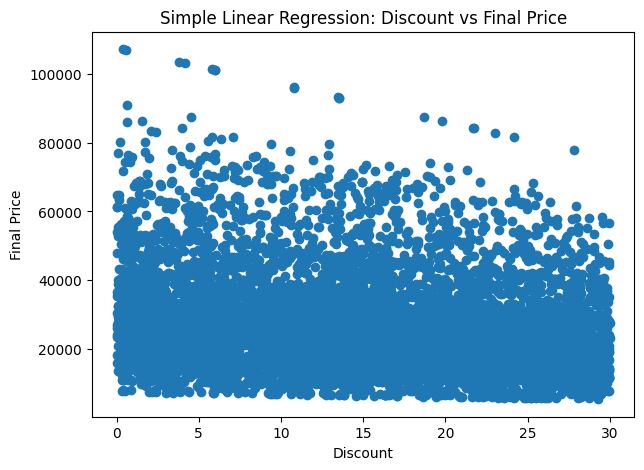

In [15]:
#SIMPLE LINEAR REGRESSION

from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

X_simple = df_encoded[["discount"]]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

y_pred_s = model_simple.predict(X_test_s)

plt.figure(figsize=(7,5))
plt.scatter(X_test_s, y_test_s)
plt.plot(X_test_s, y_pred_s)
plt.title("Simple Linear Regression: Discount vs Final Price")
plt.xlabel("Discount")
plt.ylabel("Final Price")
plt.show()

In [16]:
#MULTIPLE REGRESSION

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

y_pred_multi = model_multi.predict(X_test)

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred_multi))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_multi)))
print("R² Score:", r2_score(y_test, y_pred_multi))

MAE: 10041.484427571959
RMSE: 13456.431684742969
R² Score: 0.0408223583802122


In [18]:
#Select numeric features only

features = ["ram_gb", "storage_gb", "discount", "rating"]
target = "final_price"

X = df[features]
y = df[target]

In [19]:
#Apply Polynomial Transformation

from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE :", mean_absolute_error(y_test, y_pred))
print("R²  :", r2_score(y_test, y_pred))

MAE : 10006.894960502479
R²  : 0.043078039087694475


In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------
# 1. Load Predictive Dataset
# ------------------------------------
df = pd.read_csv(r"C:\Users\TANU\Documents\EDA\regression_dataset.csv")

# ------------------------------------
# 2. Features & Target
# ------------------------------------
X = df.drop("final_price", axis=1)
y = df["final_price"]

# Identify numeric vs categorical
numeric_features = ["revenue", "discount", "ram_gb", "storage_gb", "rating"]
categorical_features = ["brand", "city"]

# ------------------------------------
# 3. Preprocessing + Polynomial + Ridge
# ------------------------------------
degree = 3   # You can change degree if needed

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

model = Pipeline([
    ("preprocess", preprocess),
    ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
    ("ridge", Ridge(alpha=1.0))
])

# ------------------------------------
# 4. Train-test split
# ------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------
# 5. Train model
# ------------------------------------
model.fit(X_train, y_train)

# ------------------------------------
# 6. Predictions
# ------------------------------------
y_pred = model.predict(X_test)

# ------------------------------------
# 7. Metrics
# ------------------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n===== POLYNOMIAL REGRESSION (Degree =", degree, ") =====")
print("MAE  :", mae)
print("RMSE :", rmse)
print("R²   :", r2)



===== POLYNOMIAL REGRESSION (Degree = 3 ) =====
MAE  : 2307.7828583297583
RMSE : 3239.1957886498
R²   : 0.9444206295453591


In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

# ============================================
# 1. LOAD YOUR REGRESSION DATASET
# ============================================
df = pd.read_csv(r"C:\Users\TANU\Documents\EDA\regression_dataset.csv")

print("Dataset Loaded:", df.shape)
print(df.head())

# 2. FEATURE SELECTION
X = df.drop("final_price", axis=1)
y = df["final_price"]

# Identify categorical + numeric features
categorical_features = ["brand", "city"]
numeric_features = [col for col in X.columns if col not in categorical_features]

# 3. PREPROCESSING PIPELINE
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

# 4. XGBOOST REGRESSOR MODEL
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", model)
])

# 5. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. TRAIN THE MODEL
pipeline.fit(X_train, y_train)

# 7. PREDICTION
y_pred = pipeline.predict(X_test)

# 8. EVALUATION METRICS
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n===== XGBoost Regression Performance =====")
print("MSE :", mse)
print("MAE :", mae)
print("R²  :", r2)


Dataset Loaded: (40000, 8)
   final_price   revenue  discount     brand  ram_gb  storage_gb  rating  \
0     22316.19  22316.19      1.05    realme       4          64     4.8   
1     26218.62  26218.62     10.48   Samsung       4         256     5.0   
2     36469.80  72939.60     13.55     Apple       6         128     3.5   
3     37230.80  37230.80      7.57     Apple      12          64     3.3   
4     35201.29  35201.29     18.79  Motorola       6          64     4.2   

        city  
0  Bangalore  
1   Ahmedbad  
2   Kolkatta  
3     Jaipur  
4   Hydrabad  

===== XGBoost Regression Performance =====
MSE : 1074223.2034682976
MAE : 435.90730817382814
R²  : 0.9943097184688893
